https://python.langchain.com/v0.1/docs/modules/model_io/prompts/quick_start/

In [1]:
import os
from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain.prompts import PromptTemplate
from langchain_community.llms.huggingface_pipeline import HuggingFacePipeline
from langchain.chains import RetrievalQA

# from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

from huggingface_hub import login
import torch



c:\Users\riman\VSCode\GenAI_Projects\GenAI\gen_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

HF_Token = os.environ['HUGGINGFACEHUB_API_TOKEN']

login(token=HF_Token)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to C:\Users\riman\.cache\huggingface\token
Login successful


In [9]:
from langchain_community.llms import HuggingFaceHub

hf=HuggingFaceHub(
    repo_id="mistralai/Mistral-7B-Instruct-v0.3", #mistralai/Mistral-7B-v0.1, meta-llama/Llama-2-7b-chat-hf
    model_kwargs={"temperature":0.1,"max_length":5000}

)
query="What is 1+1?"
response = hf.invoke(query)

response

'What is 1+1?\n\nThe answer to this question is 2. This is a basic arithmetic operation that most people learn in early childhood. However, the question itself can be interpreted in different ways, leading to different answers. For example, in the context of set theory, the union of two sets is the set that contains all the elements of the original sets. In this case, the answer would be the set {1,2}. In the context of computer programming, the answer could be the binary'

In [ ]:
# def get_completion(prompt, model=llm_model):
#     messages = [{"role": "user", "content": prompt}]
#     response = hf.create_chat_completion(
#         model=model,
#         messages=messages,
#         temperature=0, 
#     )
#     return response.choices[0].message["content"]

# response = get_completion(prompt)
# response

## Prompt Template

In [52]:
customer_email = """
Arrr, I be fuming that me blender lid \
flew off and splattered me kitchen walls \
with smoothie! And to make matters worse,\
the warranty don't cover the cost of \
cleaning up me kitchen. I need yer help \
right now, matey!
"""

style = """American English \
in a calm and respectful tone
"""

template_string = f"""Translate the text \
that is delimited by triple backticks 
into a style that is {style}.
text: ```{customer_email}```
"""

prompt = PromptTemplate(template=template_string, input_variables=["customer_email", "style"])

response=hf(prompt.format(style=style,input_text=customer_email))
print(response)

Translate the text that is delimited by triple backticks 
into a style that is American English in a calm and respectful tone
.
text: ```
Arrr, I be fuming that me blender lid flew off and splattered me kitchen walls with smoothie! And to make matters worse,the warranty don't cover the cost of cleaning up me kitchen. I need yer help right now, matey!
```

"Arrgh, I'm absolutely furious that my blender lid flew off and splattered my kitchen walls with smoothie! And to make matters worse, the warranty doesn't cover the cost of cleaning up my kitchen. I urgently need your assistance, friend!"


In [49]:
# from langchain.prompts import ChatPromptTemplate
# # prompt_template = ChatPromptTemplate.from_template(template_string)


# # prompt_template.messages[0].prompt
# # prompt_template.messages[0].prompt.input_variables

Translate the text that is delimited by triple backticks 
into a style that is American English in a calm and respectful tone
.
text: ```
Arrr, I be fuming that me blender lid flew off and splattered me kitchen walls with smoothie! And to make matters worse,the warranty don't cover the cost of cleaning up me kitchen. I need yer help right now, matey!
```

"Arrgh, I'm absolutely furious that my blender lid flew off and splattered my kitchen walls with smoothie! And to make matters worse, the warranty doesn't cover the cost of cleaning up my kitchen. I urgently need your assistance, friend!"


In [94]:
service_reply = """Hey there customer, \
the warranty does not cover \
cleaning expenses for your kitchen \
because it's your fault that \
you misused your blender \
by forgetting to put the lid on before \
starting the blender. \
Tough luck! See ya!
"""

service_style_pirate = """\
a polite tone \
that speaks in English Pirate\
"""

template_string = f"""Translate the text \
that is delimited by triple backticks 
into a style that is {service_style_pirate}.
text: ```{service_reply}```
"""

prompt = PromptTemplate(template=template_string, input_variables=["service_reply", "service_style_pirate"])

response=hf(prompt.format(style=service_style_pirate,input_text=service_reply))
print(response)

# service_messages = prompt_template.format_messages(
#     style=service_style_pirate,
#     text=service_reply)

# print(service_messages[0].content)

# service_response = hf(str(service_messages))
# print(service_response)

Translate the text that is delimited by triple backticks 
into a style that is a polite tone that speaks in English Pirate.
text: ```Hey there customer, the warranty does not cover cleaning expenses for your kitchen because it's your fault that you misused your blender by forgetting to put the lid on before starting the blender. Tough luck! See ya!
```

Ahoy there, me hearty! 'Tis a shame to inform ye, but yer warranty be not extendin' to cover yer cleanin' expenses for yer kitchen, seein' as it be yer own fault that ye forgot to secure the lid on yer blender afore startin' it. A blunder, I be sayin'. But fear not, me hearty! Yer misfortune be not our delight, and we be wish


## Output Parsers

Let's start with defining how we would like the LLM output to look like:

In [ ]:
{
  "gift": False,
  "delivery_days": 5,
  "price_value": "pretty affordable!"
}

In [95]:
customer_review = """\
This leaf blower is pretty amazing.  It has four settings:\
candle blower, gentle breeze, windy city, and tornado. \
It arrived in two days, just in time for my wife's \
anniversary present. \
I think my wife liked it so much she was speechless. \
So far I've been the only one using it, and I've been \
using it every other morning to clear the leaves on our lawn. \
It's slightly more expensive than the other leaf blowers \
out there, but I think it's worth it for the extra features.
"""

review_template = """\
For the following text, extract the following information:

gift: Was the item purchased as a gift for someone else? \
Answer True if yes, False if not or unknown.

delivery_days: How many days did it take for the product \
to arrive? If this information is not found, output -1.

price_value: Extract any sentences about the value or price,\
and output them as a comma separated Python list.

Format the output as JSON with the following keys:
gift
delivery_days
price_value

text: {text}
"""

prompt_template = PromptTemplate(template=review_template, input_variables=["customer_review"])

response=hf(prompt_template.format(text=customer_review))
print(response)

For the following text, extract the following information:

gift: Was the item purchased as a gift for someone else? Answer True if yes, False if not or unknown.

delivery_days: How many days did it take for the product to arrive? If this information is not found, output -1.

price_value: Extract any sentences about the value or price,and output them as a comma separated Python list.

Format the output as JSON with the following keys:
gift
delivery_days
price_value

text: This leaf blower is pretty amazing.  It has four settings:candle blower, gentle breeze, windy city, and tornado. It arrived in two days, just in time for my wife's anniversary present. I think my wife liked it so much she was speechless. So far I've been the only one using it, and I've been using it every other morning to clear the leaves on our lawn. It's slightly more expensive than the other leaf blowers out there, but I think it's worth it for the extra features.

{
"gift": true,
"delivery_days": 2,
"price_value":

In [96]:
prompt_template = PromptTemplate.from_template(review_template)

response=hf(prompt_template.format(text=customer_review))
print(response)

For the following text, extract the following information:

gift: Was the item purchased as a gift for someone else? Answer True if yes, False if not or unknown.

delivery_days: How many days did it take for the product to arrive? If this information is not found, output -1.

price_value: Extract any sentences about the value or price,and output them as a comma separated Python list.

Format the output as JSON with the following keys:
gift
delivery_days
price_value

text: This leaf blower is pretty amazing.  It has four settings:candle blower, gentle breeze, windy city, and tornado. It arrived in two days, just in time for my wife's anniversary present. I think my wife liked it so much she was speechless. So far I've been the only one using it, and I've been using it every other morning to clear the leaves on our lawn. It's slightly more expensive than the other leaf blowers out there, but I think it's worth it for the extra features.

{
"gift": true,
"delivery_days": 2,
"price_value":

In [83]:
from langchain.output_parsers import ResponseSchema
from langchain.output_parsers import StructuredOutputParser

In [84]:
gift_schema = ResponseSchema(name="gift",
                             description="Was the item purchased\
                             as a gift for someone else? \
                             Answer True if yes,\
                             False if not or unknown.")
delivery_days_schema = ResponseSchema(name="delivery_days",
                                      description="How many days\
                                      did it take for the product\
                                      to arrive? If this \
                                      information is not found,\
                                      output -1.")
price_value_schema = ResponseSchema(name="price_value",
                                    description="Extract any\
                                    sentences about the value or \
                                    price, and output them as a \
                                    comma separated Python list.")

response_schemas = [gift_schema, 
                    delivery_days_schema,
                    price_value_schema]

In [85]:
output_parser = StructuredOutputParser.from_response_schemas(response_schemas)
format_instructions = output_parser.get_format_instructions()
print(format_instructions)

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing "```json" and "```":

```json
{
	"gift": string  // Was the item purchased                             as a gift for someone else?                              Answer True if yes,                             False if not or unknown.
	"delivery_days": string  // How many days                                      did it take for the product                                      to arrive? If this                                       information is not found,                                      output -1.
	"price_value": string  // Extract any                                    sentences about the value or                                     price, and output them as a                                     comma separated Python list.
}
```


In [98]:
review_template_2 = """\
For the following text, extract the following information:

gift: Was the item purchased as a gift for someone else? \
Answer True if yes, False if not or unknown.

delivery_days: How many days did it take for the product\
to arrive? If this information is not found, output -1.

price_value: Extract any sentences about the value or price,\
and output them as a comma separated Python list.

text: {text}

{format_instructions}
"""
prompt_template = PromptTemplate.from_template(review_template_2)

response = prompt.format(text=customer_review,
                                format_instructions=format_instructions)

print(response)

# output_dict = output_parser.parse(response)

Translate the text that is delimited by triple backticks 
into a style that is a polite tone that speaks in English Pirate.
text: ```Hey there customer, the warranty does not cover cleaning expenses for your kitchen because it's your fault that you misused your blender by forgetting to put the lid on before starting the blender. Tough luck! See ya!
```



## Memory

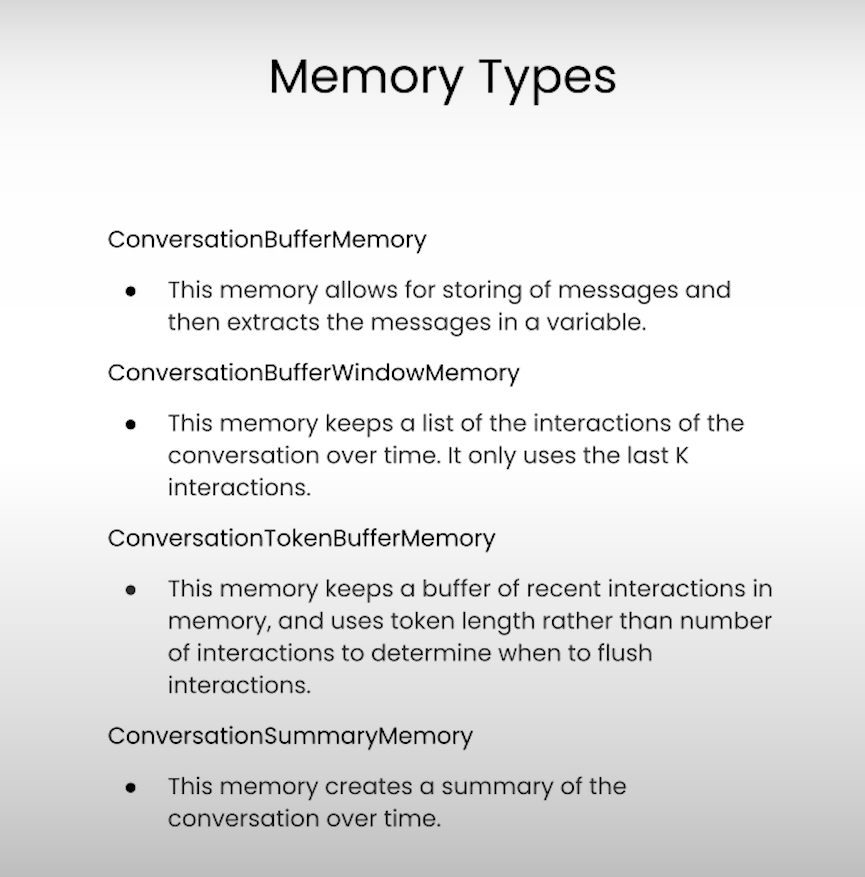

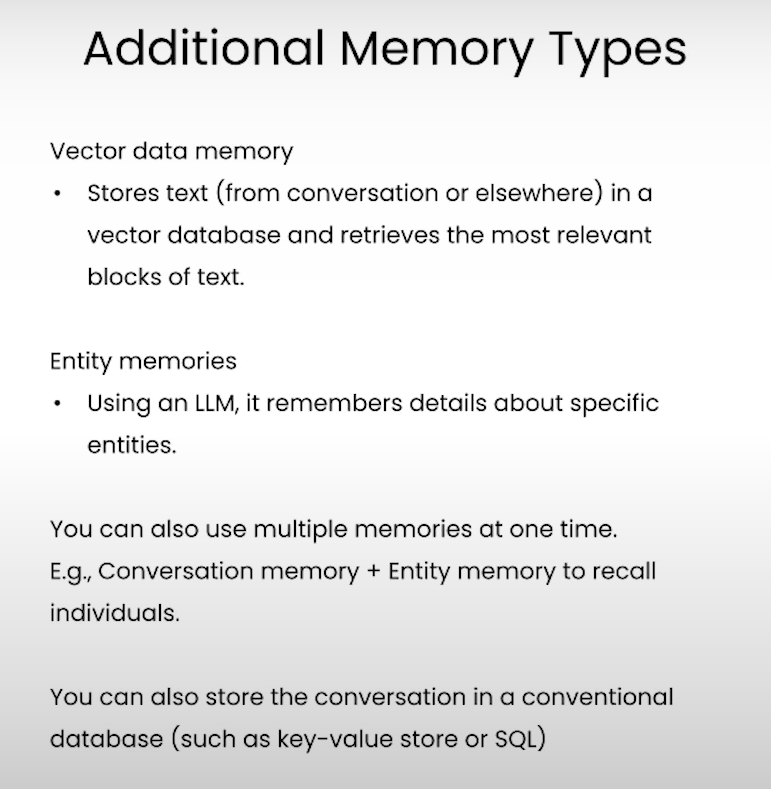

In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory, ConversationBufferWindowMemory,ConversationTokenBufferMemory, ConversationSummaryBufferMemory

In [ ]:
llm = ChatOpenAI(temperature=0.0, model=llm_model)
memory = ConversationBufferMemory()
conversation = ConversationChain(
    llm=llm, 
    memory = memory,
    verbose=True
)

conversation.predict(input="Hi, my name is Andrew")
conversation.predict(input="What is 1+1?")
conversation.predict(input="What is my name?")
print(memory.buffer) # it will print all history
memory.load_memory_variables({})

In [ ]:
memory = ConversationBufferWindowMemory(k=1)
memory.save_context({"input": "Hi"},
                    {"output": "What's up"})
memory.save_context({"input": "Not much, just hanging"},
                    {"output": "Cool"})
memory.load_memory_variables({})
llm = ChatOpenAI(temperature=0.0, model=llm_model)
memory = ConversationBufferWindowMemory(k=1)
conversation = ConversationChain(
    llm=llm, 
    memory = memory,
    verbose=False
)
conversation.predict(input="Hi, my name is Andrew")

In [ ]:

llm = ChatOpenAI(temperature=0.0, model=llm_model)
memory = ConversationTokenBufferMemory(llm=llm, max_token_limit=50)
memory.save_context({"input": "AI is what?!"},
                    {"output": "Amazing!"})
memory.save_context({"input": "Backpropagation is what?"},
                    {"output": "Beautiful!"})
memory.save_context({"input": "Chatbots are what?"}, 
                    {"output": "Charming!"})

memory.load_memory_variables({})

In [ ]:
# create a long string
schedule = "There is a meeting at 8am with your product team. \
You will need your powerpoint presentation prepared. \
9am-12pm have time to work on your LangChain \
project which will go quickly because Langchain is such a powerful tool. \
At Noon, lunch at the italian resturant with a customer who is driving \
from over an hour away to meet you to understand the latest in AI. \
Be sure to bring your laptop to show the latest LLM demo."

memory = ConversationSummaryBufferMemory(llm=llm, max_token_limit=100)
memory.save_context({"input": "Hello"}, {"output": "What's up"})
memory.save_context({"input": "Not much, just hanging"},
                    {"output": "Cool"})
memory.save_context({"input": "What is on the schedule today?"}, 
                    {"output": f"{schedule}"})

memory.load_memory_variables({})

conversation = ConversationChain(
    llm=llm, 
    memory = memory,
    verbose=True
)

conversation.predict(input="What would be a good demo to show?")

memory.load_memory_variables({})